In [31]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import gymnasium as gym
import matplotlib.pyplot as plt

In [32]:
# Actor network
class Actor(nn.Module):
  def __init__(self, state_size, action_size):
    super().__init__()
    self.anet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, action_size)
    )

  def forward(self, x):
    return self.anet(x)

# Critic network
class Critic(nn.Module):
  def __init__(self, state_size):
    super().__init__()
    self.cnet = nn.Sequential(
        nn.Linear(state_size, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    )

  def forward(self, x):
    return self.cnet(x)

In [33]:
# instantiate the env & network
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
actor = Actor(state_size, action_size)
critic = Critic(state_size)

# define optimizer
actor_optimizer = optim.Adam(actor.parameters(), lr=3e-4)
critic_optimizer = optim.Adam(critic.parameters(), lr=3e-4)
# define loss for critic
C_criterion = nn.MSELoss()
# hyperparamters
gamma = 0.99

In [34]:
max_episode = 600
episode_rew = []
for i in range(max_episode):
  state, _ = env.reset()
  done = False
  state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
  rewards = []

  while not done:
    # get value function V
    value = critic(state)

    # get action and logprob
    logits = actor(state)
    dist = Categorical(logits=logits) # no tensor output yet, just a distribution object parameterized by those probs
    act = dist.sample()
    logprob = dist.log_prob(act).unsqueeze(0)

    # take a step
    next_state, reward, terminated, truncated, _ = env.step(act.item())
    done = terminated or truncated
    # record reward
    rewards.append(reward)

    next_state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)

    # get next_value function
    with torch.no_grad():
      next_value = critic(next_state)

    # compute actor & critic loss
    target = reward + gamma * next_value * (1 - done)
    actor_loss = -(logprob * (target - value.detach()))
    critic_loss = C_criterion(target, value)
    # update actor network
    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()
    # update critic network
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    state = next_state

    if done:
      episode_rew.append(sum(rewards))
      print(f'episode_length: {sum(rewards)}')

episode_length: 21.0
episode_length: 22.0
episode_length: 13.0
episode_length: 14.0
episode_length: 23.0
episode_length: 35.0
episode_length: 19.0
episode_length: 11.0
episode_length: 19.0
episode_length: 38.0
episode_length: 25.0
episode_length: 10.0
episode_length: 20.0
episode_length: 22.0
episode_length: 9.0
episode_length: 16.0
episode_length: 14.0
episode_length: 12.0
episode_length: 20.0
episode_length: 28.0
episode_length: 17.0
episode_length: 14.0
episode_length: 15.0
episode_length: 21.0
episode_length: 11.0
episode_length: 14.0
episode_length: 22.0
episode_length: 22.0
episode_length: 17.0
episode_length: 16.0
episode_length: 11.0
episode_length: 25.0
episode_length: 21.0
episode_length: 14.0
episode_length: 20.0
episode_length: 10.0
episode_length: 11.0
episode_length: 14.0
episode_length: 28.0
episode_length: 13.0
episode_length: 11.0
episode_length: 12.0
episode_length: 9.0
episode_length: 28.0
episode_length: 45.0
episode_length: 13.0
episode_length: 10.0
episode_length:

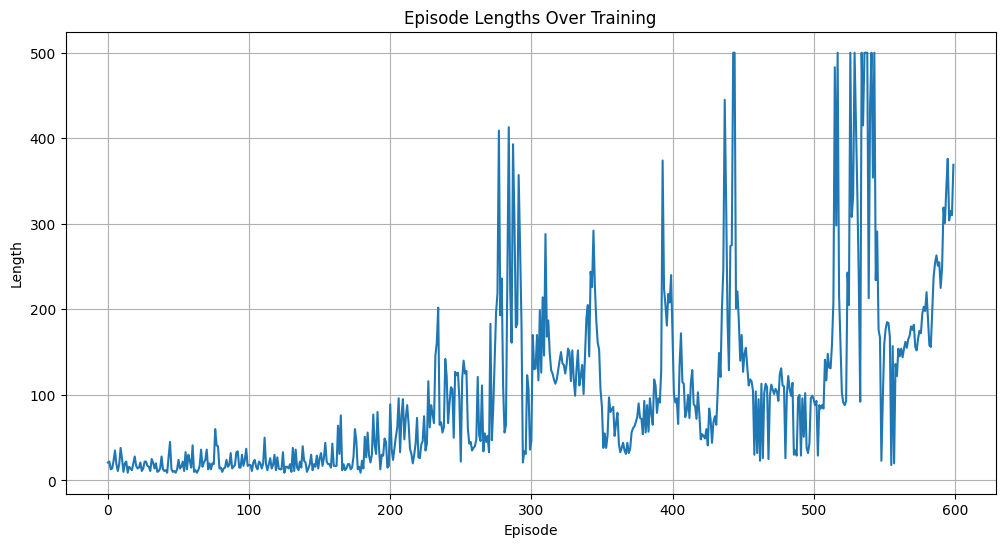

In [35]:
# Plot the collected episode lengths
plt.figure(figsize=(12, 6))
plt.plot(episode_rew)
plt.title('Episode Lengths Over Training')
plt.xlabel('Episode')
plt.ylabel('Length')
plt.grid(True)
plt.show()